<a href="https://colab.research.google.com/github/UKD1211/100_days_ML_cX_ISI_DS/blob/main/AdaBoost/AdaBoost_scratch_own_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification

In [2]:
X,y = make_classification(n_features = 2,n_clusters_per_class=2,n_informative = 2,n_redundant= 0 ,n_samples = 100)

# Combine X and y into a single array with 3 columns
# X has shape (100, 2) and y has shape (100,)
# Reshape y to (100, 1) to concatenate horizontally
combined_data = np.hstack((X, y.reshape(-1, 1)))

df = pd.DataFrame(combined_data, columns = ['f1','f2','target'])

<Axes: >

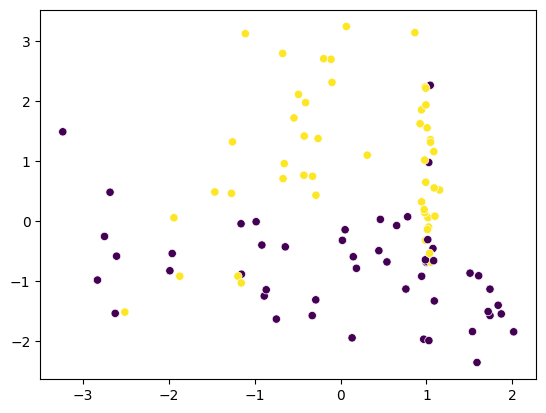

In [3]:
import seaborn as sns
sns.scatterplot(x = X[:,0],y = X[:,1],c = y)

In [4]:
#for the ada boost i have to start with the decision stump here how , we will do ?

df['weight'] = 1/df.shape[0]
df.head()

,f1,f2,target,weight
0,1.008055,1.558098,1.0,0.01
1,1.588689,-2.350697,0.0,0.01
2,0.942430,1.857480,1.0,0.01
3,0.989960,-0.316948,1.0,0.01
4,-1.257936,1.324791,1.0,0.01


[Text(0.5, 0.75, 'x[1] <= 0.047\ngini = 0.5\nsamples = 100\nvalue = [51, 49]'),
 Text(0.25, 0.25, 'gini = 0.274\nsamples = 55\nvalue = [46, 9]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.198\nsamples = 45\nvalue = [5, 40]'),
 Text(0.625, 0.5, '  False')]

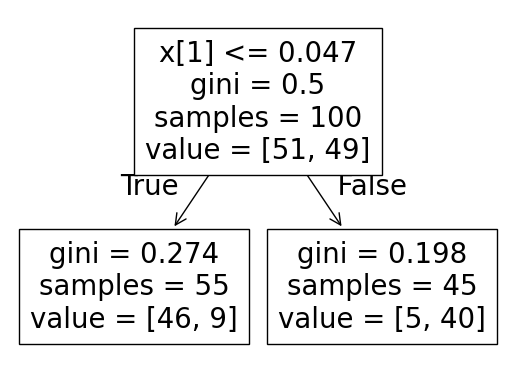

In [5]:
#DECISIONstump
from sklearn.tree import DecisionTreeClassifier,plot_tree
dt1 = DecisionTreeClassifier(max_depth = 1)
dt1.fit(X,y)
plot_tree(dt1)

In [6]:
from sklearn.metrics import accuracy_score

In [7]:
accuracy_score(y, dt1.predict(X))

0.86

In [8]:
df['predict'] = dt1.predict(X)
df

,f1,f2,target,weight,predict
0,1.008055,1.558098,1.0,0.01,1
1,1.588689,-2.350697,0.0,0.01,0
2,0.942430,1.857480,1.0,0.01,1
3,0.989960,-0.316948,1.0,0.01,0
4,-1.257936,1.324791,1.0,0.01,1
...,...,...,...,...,...
95,0.653566,-0.069738,0.0,0.01,0
96,0.926181,1.626965,1.0,0.01,1
97,1.028735,-1.985867,0.0,0.01,0
98,-0.864784,-1.139301,0.0,0.01,0


In [9]:
error1 = (df[~(df['target'] == df['predict'])]['weight'].sum())
error1

np.float64(0.13999999999999999)

In [10]:
# to get the alpha values here , we will apply the formula
alpha1 = (1/2) * np.log((1 - error1)/error1)

In [11]:
alpha1

np.float64(0.9076449833191246)

In [12]:
#now everything is not correct this , tree  kaeking some  mistakes , so , we will want to rectify those problems , by assigning the upsampling or the higherweights there easily , very easily

df

,f1,f2,target,weight,predict
0,1.008055,1.558098,1.0,0.01,1
1,1.588689,-2.350697,0.0,0.01,0
2,0.942430,1.857480,1.0,0.01,1
3,0.989960,-0.316948,1.0,0.01,0
4,-1.257936,1.324791,1.0,0.01,1
...,...,...,...,...,...
95,0.653566,-0.069738,0.0,0.01,0
96,0.926181,1.626965,1.0,0.01,1
97,1.028735,-1.985867,0.0,0.01,0
98,-0.864784,-1.139301,0.0,0.01,0


In [13]:
# Update weights for misclassified samples
df.loc[~(df['target'] == df['predict']), 'weight'] = df.loc[~(df['target'] == df['predict']), 'weight'] * np.exp(alpha1)

# Update weights for correctly classified samples
df.loc[(df['target'] == df['predict']), 'weight'] = df.loc[(df['target'] == df['predict']), 'weight'] * np.exp(-alpha1)

# Normalize the weights
df['weight'] = df['weight'] / df['weight'].sum()

In [14]:
df = df.drop(columns = 'predict')

In [15]:
np.cumsum(df['weight'].ravel())

/tmp/ipykernel_314/1025032676.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  np.cumsum(df['weight'].ravel())


array([0.00581395, 0.01162791, 0.01744186, 0.05315615, 0.0589701 ,
       0.06478405, 0.10049834, 0.10631229, 0.11212625, 0.14784053,
       0.15365449, 0.15946844, 0.16528239, 0.20099668, 0.23671096,
       0.24252492, 0.24833887, 0.25415282, 0.25996678, 0.26578073,
       0.27159468, 0.27740864, 0.28322259, 0.31893688, 0.32475083,
       0.33056478, 0.33637874, 0.34219269, 0.34800664, 0.3538206 ,
       0.35963455, 0.3654485 , 0.37126246, 0.37707641, 0.38289037,
       0.38870432, 0.39451827, 0.40033223, 0.40614618, 0.41196013,
       0.41777409, 0.42358804, 0.42940199, 0.43521595, 0.47093023,
       0.47674419, 0.48255814, 0.48837209, 0.49418605, 0.5       ,
       0.53571429, 0.54152824, 0.54734219, 0.58305648, 0.58887043,
       0.59468439, 0.60049834, 0.63621262, 0.64202658, 0.64784053,
       0.65365449, 0.65946844, 0.66528239, 0.67109635, 0.6769103 ,
       0.68272425, 0.68853821, 0.72425249, 0.73006645, 0.7358804 ,
       0.77159468, 0.77740864, 0.78322259, 0.78903654, 0.79485

In [16]:
def range_test():
  cumsum_weights = np.cumsum(df['weight'].to_numpy())
  ranges = []
  # Start from 0
  ranges.append(f"0.0 - {cumsum_weights[0]:.4f}")
  for i in range(len(cumsum_weights) - 1):
    ranges.append(f"{cumsum_weights[i]:.4f} - {cumsum_weights[i+1]:.4f}")
  return ranges

range_test()

['0.0 - 0.0058',
 '0.0058 - 0.0116',
 '0.0116 - 0.0174',
 '0.0174 - 0.0532',
 '0.0532 - 0.0590',
 '0.0590 - 0.0648',
 '0.0648 - 0.1005',
 '0.1005 - 0.1063',
 '0.1063 - 0.1121',
 '0.1121 - 0.1478',
 '0.1478 - 0.1537',
 '0.1537 - 0.1595',
 '0.1595 - 0.1653',
 '0.1653 - 0.2010',
 '0.2010 - 0.2367',
 '0.2367 - 0.2425',
 '0.2425 - 0.2483',
 '0.2483 - 0.2542',
 '0.2542 - 0.2600',
 '0.2600 - 0.2658',
 '0.2658 - 0.2716',
 '0.2716 - 0.2774',
 '0.2774 - 0.2832',
 '0.2832 - 0.3189',
 '0.3189 - 0.3248',
 '0.3248 - 0.3306',
 '0.3306 - 0.3364',
 '0.3364 - 0.3422',
 '0.3422 - 0.3480',
 '0.3480 - 0.3538',
 '0.3538 - 0.3596',
 '0.3596 - 0.3654',
 '0.3654 - 0.3713',
 '0.3713 - 0.3771',
 '0.3771 - 0.3829',
 '0.3829 - 0.3887',
 '0.3887 - 0.3945',
 '0.3945 - 0.4003',
 '0.4003 - 0.4061',
 '0.4061 - 0.4120',
 '0.4120 - 0.4178',
 '0.4178 - 0.4236',
 '0.4236 - 0.4294',
 '0.4294 - 0.4352',
 '0.4352 - 0.4709',
 '0.4709 - 0.4767',
 '0.4767 - 0.4826',
 '0.4826 - 0.4884',
 '0.4884 - 0.4942',
 '0.4942 - 0.5000',
 '0

In [17]:
df['range'] = pd.DataFrame(np.array(range_test()))

In [18]:
df['weight'].sort_values(ascending = False)

,weight
3,0.035714
14,0.035714
9,0.035714
6,0.035714
23,0.035714
...,...
95,0.005814
96,0.005814
97,0.005814
98,0.005814


In [19]:
arr = np.random.rand(100)

In [20]:
df['range'].str.split(" - ")[10]

['0.1478', '0.1537']

In [21]:
df['range'].str.split("-").str[1]

,range
0,0.0058
1,0.0116
2,0.0174
3,0.0532
4,0.0590
...,...
95,0.9767
96,0.9826
97,0.9884
98,0.9942


In [22]:
arr

array([0.0918477 , 0.35439601, 0.38331559, 0.62369873, 0.7444397 ,
       0.56975513, 0.70800142, 0.52780527, 0.00929023, 0.9889726 ,
       0.94202436, 0.51120296, 0.1129306 , 0.16173838, 0.19359716,
       0.47653888, 0.49792028, 0.53779088, 0.16637851, 0.64249482,
       0.99649814, 0.68256678, 0.72721474, 0.74873837, 0.40670183,
       0.65451628, 0.25574234, 0.27468195, 0.84876157, 0.55537938,
       0.41273629, 0.4530336 , 0.39704561, 0.76477787, 0.7299025 ,
       0.73419912, 0.31140718, 0.34974105, 0.83955199, 0.21030534,
       0.51909052, 0.60863253, 0.37254517, 0.70120388, 0.17739155,
       0.18431455, 0.20976904, 0.79900216, 0.54391861, 0.68542806,
       0.51584635, 0.01129685, 0.21002083, 0.00693699, 0.67001513,
       0.16537475, 0.21107496, 0.29608849, 0.28166719, 0.05403726,
       0.11357941, 0.88392747, 0.37810369, 0.46737197, 0.28113154,
       0.69455574, 0.54767162, 0.15926211, 0.05018112, 0.09357743,
       0.53694366, 0.07049369, 0.87004145, 0.55415729, 0.87385

In [23]:
for i in arr:
  # Convert to numpy array to iterate over the lists of [start, end]
  for j in df['range'].str.split(" - ").to_numpy():
    # j is a list like ['0.0', '0.0054']
    if i >= float(j[0]) and i <= float(j[1]):
      print(f"{i} falls in range {j[0]} - {j[1]}")
      break

0.09184770306972179 falls in range 0.0648 - 0.1005
0.35439601472395277 falls in range 0.3538 - 0.3596
0.3833155895162611 falls in range 0.3829 - 0.3887
0.623698729267396 falls in range 0.6005 - 0.6362
0.7444397000689977 falls in range 0.7359 - 0.7716
0.5697551337142736 falls in range 0.5473 - 0.5831
0.7080014188281178 falls in range 0.6885 - 0.7243
0.5278052666776076 falls in range 0.5000 - 0.5357
0.009290225330336632 falls in range 0.0058 - 0.0116
0.9889726020254002 falls in range 0.9884 - 0.9942
0.9420243584055124 falls in range 0.9419 - 0.9477
0.5112029556082964 falls in range 0.5000 - 0.5357
0.11293060113643238 falls in range 0.1121 - 0.1478
0.1617383796573557 falls in range 0.1595 - 0.1653
0.1935971591329536 falls in range 0.1653 - 0.2010
0.4765388760826875 falls in range 0.4709 - 0.4767
0.49792027919928616 falls in range 0.4942 - 0.5000
0.5377908841171775 falls in range 0.5357 - 0.5415
0.16637850622278116 falls in range 0.1653 - 0.2010
0.6424948222134635 falls in range 0.6420 - 0

In [24]:
new_rows = []

for val in arr:
    # Iterate through the DataFrame to find which range the random value falls into
    for idx, row in df.iterrows():
        range_parts = row['range'].split(" - ")
        start, end = float(range_parts[0]), float(range_parts[1])

        if start <= val <= end:
            new_rows.append(row)
            break

# Create the new DataFrame from the collected rows
df_new = pd.DataFrame(new_rows).reset_index(drop=True)

print(f"Created new dataframe with {len(df_new)} rows.")
display(df_new.head())

Created new dataframe with 100 rows.


,f1,f2,target,weight,range
0,1.027522,0.981678,0.0,0.035714,0.0648 - 0.1005
1,-0.099493,2.315053,1.0,0.005814,0.3538 - 0.3596
2,0.979127,1.021226,1.0,0.005814,0.3829 - 0.3887
3,1.044013,2.267360,0.0,0.035714,0.6005 - 0.6362
4,-1.155174,-1.025716,1.0,0.035714,0.7359 - 0.7716


In [27]:
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators = 100)
ada.fit(X,y)

AdaBoostClassifier(n_estimators=100)

In [32]:
ada.estimator_weights_

array([0.07387644, 0.07426986, 0.07500484, 0.07532227, 0.0756404 ,
       0.07792878, 0.08066538, 0.08109007, 0.0878637 , 0.09467352,
       0.09629743, 0.09692997, 0.09938161, 0.10089578, 0.10187122,
       0.10298925, 0.10626122, 0.1072741 , 0.10734383, 0.10858606,
       0.10900776, 0.10972199, 0.11223   , 0.11299903, 0.11438461,
       0.11891006, 0.11977383, 0.12133189, 0.12852821, 0.1309382 ,
       0.13419744, 0.13617099, 0.13765739, 0.14373293, 0.14386622,
       0.14462438, 0.14857145, 0.155855  , 0.15800155, 0.16086398,
       0.16554569, 0.16815725, 0.17067758, 0.17390786, 0.17578837,
       0.18075077, 0.18363696, 0.18399686, 0.18617561, 0.18849963,
       0.19247422, 0.19345347, 0.19460029, 0.19624525, 0.19747973,
       0.20185433, 0.2022663 , 0.20344767, 0.20535239, 0.20686597,
       0.20875655, 0.21553517, 0.21565726, 0.21587173, 0.21666052,
       0.21920189, 0.22460929, 0.22772762, 0.23203222, 0.23427479,
       0.234658  , 0.23841802, 0.25087787, 0.25249697, 0.25540

# **Will make a class on this**

In [25]:
class Adaboost_UKD:
  def __init__(self,n_estimators = 50):